<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> Mid-Term Assignment - CSV to Data Warehouse </b></h3>

<div style="background-color:#f8f9fa; padding:15px; border-radius:10px; border:1px solid #FF8DA1;">
<h3><b> Table of Contents</b></h3>

1. [Introduction and Selection of Dataset](#introduction)
2. [Libraries and Environment Setup](#libraries)
3. [Data Loading and Merging](#load)
4. [Data Cleaning](#clean)
5. [Star Schema: Dimensions Construction](#dimensions)
5. [Fact Table Construction](#fact-table)
6. [SQL Queries and Analysis](#sql-queries-and-analysis)
8. [Conclusion](#conclusion)
</div>

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="introduction"></a> Introduction and Selection of Dataset </b></h3>

### **Introduction & Project Goals**

The primary goal of this project is to build a **Star Schema Data Warehouse** by transforming a raw CSV dataset using **Python and SQLite**. This work focuses on the entire ETL cycle: extracting raw data, transforming formats, and loading them into a **centralized analytical database** for the movie industry.


### **Dataset Selection**

After evaluating all the three dataset options, the **TMDB 5000 Movies Dataset** was selected out of the list for the following reasons:

- **Meaningful Insights**: The variety of attributes allows for creative and especially useful business insights, such as comparing success across different genres or directors and if the movie's release date is a key factor in a movie's sucess, helping determine the best timing for future releases.

- **Dataset Structure**: The way the data is organized made it a really good option to build a solid Star Schema with a clear Fact table and meaningful Dimensions.

- **Personal Interest in the Theme**: Working with movie data is much more engaging and intuitive than medical records or music technicalities, making the analysis process more interesting for our group.

### TMDB Movie Metadata — Movies Table

| Column | Description |
|--------|-------------|
| budget | Estimated production budget of the movie |
| genres | List of movie genres (stored as JSON-like text) |
| homepage | Official movie homepage URL, if available |
| id | Unique identifier for the movie |
| keywords | List of plot-related keywords/tags |
| original_language | Original language of the movie |
| original_title | Original title of the movie |
| overview | Short summary or description of the movie |
| popularity | Popularity score assigned by TMDB |
| production_companies | List of production companies involved |
| production_countries | List of countries where the movie was produced |
| release_date | Official release date of the movie |
| revenue | Total revenue generated by the movie |
| runtime | Duration of the movie in minutes |
| spoken_languages | Languages spoken in the movie |
| status | Release status (e.g., Released) |
| tagline | Promotional slogan or tagline |
| title | Display title of the movie |
| vote_average | Average user rating |
| vote_count | Number of user votes received |

### TMDB Movie Metadata — Credits Table

| Column | Description |
|--------|-------------|
| movie_id | Unique identifier linking the credits to a movie |
| title | Title of the movie |
| cast | List of cast members (stored as JSON-like text) |
| crew | List of crew members such as director, producer, etc. |

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="libraries"></a> Libraries and Environment Setup </b></h3>

In [1]:
import pandas as pd
import numpy as np
import ast #allow us to explode information in a json format
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns



#display configuration to avoid scientific notation (e+09)
pd.options.display.float_format = '{:.2f}'.format

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="load"></a> Data Loading and Merging </b></h3>

The TMDB 5000 dataset is provided as two separate CSV files. 
One containing **general movie data**, such as budget, revenue, genres (df_1) and another containing **specific credits** , like cast and crew (df_2). The first step was to load both files and **merge them into a single DataFrame**. We performed this merge using the **unique movie ID** present in both files. 


This was a crucial step to ensure that, later on, the metrics could be correctly linked to each other. 

In [2]:
df_1 = pd.read_csv('tmdb_5000_movies.csv')
df_2 = pd.read_csv('tmdb_5000_credits.csv')


#merging based on the unique ID
#the 'id' in df_1 and 'movie_id' in df_2 are the same entity
df_combined = pd.merge(df_1, df_2, left_on = 'id', right_on = 'movie_id')

#cleaning up redundant information after merging
df_combined.drop(columns= ['movie_id', 'title_y'], inplace = True)
df_combined.rename(columns= {'title_x' : 'title'}, inplace= True)

In [3]:
#quick exploration
print(f"Dataset Dimensions: {df_combined.shape}")

Dataset Dimensions: (4803, 22)


<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="clean"></a> Data Cleaning ( Missing Values, Duplicate Records, Change Datatypes) </b></h3>

#### **Handling Missing Values**

Having missing values in our fact table and/or dimensions can be a large problem because it directly affects the accuracy of some business metrics and the reliability of our SQL joins.

In [4]:
df_combined.isna().sum() #to check the missing values per columns

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                       0
crew                       0
dtype: int64

In [5]:
'''
In the case of release_date and runtime which only have 1 and 2 missing values,
respectively, we chose to drop these rows.
Since the dataset contains 4803 records, losing 3 rows (less than 0.1% of the data) 
is insignificant and ensures that the dimensions remain accurate
without having to impute or guess these values.
'''

df_combined = df_combined.dropna(subset=['release_date'])
df_combined = df_combined.dropna(subset=['runtime'])

In [6]:
#dropping columns that are not necessary for the Star Schema
#by dropping, we focus only on the attributes that drive meaningful insights

df_combined.drop(columns = ['homepage', 'tagline', 'overview', 'keywords', 'status'], inplace = True)

#### **Handling Duplicate Records**

In [7]:
#checking for duplicate records
duplicate_count = df_combined.duplicated().sum()
print(f"Number of duplicate records found: {duplicate_count}")

Number of duplicate records found: 0


#### **Checking Data Types**

In [8]:
df_combined.dtypes

budget                    int64
genres                   object
id                        int64
original_language        object
original_title           object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
title                    object
vote_average            float64
vote_count                int64
cast                     object
crew                     object
dtype: object

In [9]:
#change some data types to allow a better analysis
df_combined['release_date'] = pd.to_datetime(df_combined['release_date'])
df_combined['budget'] = pd.to_numeric(df_combined['budget'], errors='coerce')
df_combined['revenue'] = pd.to_numeric(df_combined['revenue'], errors='coerce')

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="dimensions" ></a>Star Schema: Dimensions Construction </b></h3>

In this stage of the project, we will separate the dataset into **four distinct Dimension tables**. 

Each dimension was carefully selected to answer **specific business questions regarding movie success**:


- **Dimension 1 - Dates**: Essential for **Time-Series analysis**. It allows us to see if movies released in specific months or quarters perform better financially.
- **Dimension 2 - Genres**: Developed by "exploding" the nested JSON strings. This allows us to attribute a single movie's success to multiple genres (e.g., Action and Comedy).
- **Dimension 3 - Cast**: Contains the actors involved in the production, enabling us to identify which "star power" correlates with higher box office revenue.
- **Dimension 4 - Production Companies**: Created by extracting and exploding the nested production company information. This dimension allows us to analyze which studios are associated with higher revenue and profit, helping identify the companies behind the most commercially successful films.

### **Dimension 1 - Dates**

The Date Dimension is the centre of any time-series analysis. By extracting the year, month, and day name from the raw release date, we can identify **seasonal trends**.

In [10]:
dim1_date = pd.DataFrame({
    'movie_id': df_combined['id'],
    'release_date': df_combined['release_date'],
    'year': pd.to_datetime(df_combined['release_date']).dt.year,
    'month': pd.to_datetime(df_combined['release_date']).dt.month,
    'quarter': pd.to_datetime(df_combined['release_date']).dt.quarter,
    'day_of_week': pd.to_datetime(df_combined['release_date']).dt.day_name()
})

In [11]:
dim1_date 

,movie_id,release_date,year,month,quarter,day_of_week
0,19995,2009-12-10,2009,12,4,Thursday
1,285,2007-05-19,2007,5,2,Saturday
2,206647,2015-10-26,2015,10,4,Monday
3,49026,2012-07-16,2012,7,3,Monday
4,49529,2012-03-07,2012,3,1,Wednesday
...,...,...,...,...,...,...
4798,9367,1992-09-04,1992,9,3,Friday
4799,72766,2011-12-26,2011,12,4,Monday
4800,231617,2013-10-13,2013,10,4,Sunday
4801,126186,2012-05-03,2012,5,2,Thursday


### **Dimension 2 - Genres**

Since a movie can belong to multiple categories, this dimension was created by **"exploding" the nested JSON data**. With this information, we can **compare the profitability and popularity** across different cinematic styles, such as Action, Comedy, or Documentary.

In [12]:
df_combined['genres'] = df_combined['genres'].apply(ast.literal_eval)
df_genres_exploded = df_combined[['id', 'genres']].explode('genres')
df_genres_exploded = df_genres_exploded.dropna(subset=['genres'])
df_genres_exploded 

,id,genres
0,19995,"{'id': 28, 'name': 'Action'}"
0,19995,"{'id': 12, 'name': 'Adventure'}"
0,19995,"{'id': 14, 'name': 'Fantasy'}"
0,19995,"{'id': 878, 'name': 'Science Fiction'}"
1,285,"{'id': 12, 'name': 'Adventure'}"
...,...,...
4800,231617,"{'id': 35, 'name': 'Comedy'}"
4800,231617,"{'id': 18, 'name': 'Drama'}"
4800,231617,"{'id': 10749, 'name': 'Romance'}"
4800,231617,"{'id': 10770, 'name': 'TV Movie'}"


In [13]:
dim2_genres = pd.DataFrame({
    'movie_id': df_genres_exploded['id'],
    'genre_id': df_genres_exploded['genres'].apply(lambda x: x['id']),
    'genre_name': df_genres_exploded['genres'].apply(lambda x: x['name'])})
dim2_genres

,movie_id,genre_id,genre_name
0,19995,28,Action
0,19995,12,Adventure
0,19995,14,Fantasy
0,19995,878,Science Fiction
1,285,12,Adventure
...,...,...,...
4800,231617,35,Comedy
4800,231617,18,Drama
4800,231617,10749,Romance
4800,231617,10770,TV Movie


### **Dimension 3 - Cast**

This third dimension stores the lead actors involved in each production. We can measure "Star Power" and analyze how the presence of **specific actors influences the movie’s overall popularity and revenue**.

In [14]:
df_combined['cast'] = df_combined['cast'].apply(ast.literal_eval)
df_cast_exploded = df_combined[['id', 'cast']].explode('cast')
df_cast_exploded = df_cast_exploded.dropna(subset=['cast'])
df_cast_exploded

,id,cast
0,19995,"{'cast_id': 242, 'character': 'Jake Sully', 'c..."
0,19995,"{'cast_id': 3, 'character': 'Neytiri', 'credit..."
0,19995,"{'cast_id': 25, 'character': 'Dr. Grace August..."
0,19995,"{'cast_id': 4, 'character': 'Col. Quaritch', '..."
0,19995,"{'cast_id': 5, 'character': 'Trudy Chacon', 'c..."
...,...,...
4802,25975,"{'cast_id': 8, 'character': 'Himself', 'credit..."
4802,25975,"{'cast_id': 9, 'character': 'Himself', 'credit..."
4802,25975,"{'cast_id': 10, 'character': 'Himself', 'credi..."
4802,25975,"{'cast_id': 11, 'character': 'Himself', 'credi..."


In [15]:
dim3_cast = pd.DataFrame({
    'movie_id': df_cast_exploded['id'],
    'actor_id': df_cast_exploded['cast'].apply(lambda x: x['id']),
    'actor_name': df_cast_exploded['cast'].apply(lambda x: x['name']),
    'character': df_cast_exploded['cast'].apply(lambda x: x['character'])
})

In [16]:
dim3_cast

,movie_id,actor_id,actor_name,character
0,19995,65731,Sam Worthington,Jake Sully
0,19995,8691,Zoe Saldana,Neytiri
0,19995,10205,Sigourney Weaver,Dr. Grace Augustine
0,19995,32747,Stephen Lang,Col. Quaritch
0,19995,17647,Michelle Rodriguez,Trudy Chacon
...,...,...,...,...
4802,25975,21315,Eric Roberts,Himself
4802,25975,2171,Griffin Dunne,Himself
4802,25975,2231,Samuel L. Jackson,Himself
4802,25975,14407,Matt LeBlanc,Himself


### **Dimension 4 - Production Companies**

In [17]:
df_combined['production_companies'] = df_combined['production_companies'].apply(ast.literal_eval)
df_production_exploded = df_combined[['id', 'production_companies']].explode('production_companies')
df_production_exploded = df_production_exploded.dropna(subset=['production_companies'])

dim4_production = pd.DataFrame({
    'movie_id': df_production_exploded['id'],
    'company_id': df_production_exploded['production_companies'].apply(lambda x: x['id']),
    'company_name': df_production_exploded['production_companies'].apply(lambda x: x['name'])
})

dim4_production.head()

,movie_id,company_id,company_name
0,19995,289,Ingenious Film Partners
0,19995,306,Twentieth Century Fox Film Corporation
0,19995,444,Dune Entertainment
0,19995,574,Lightstorm Entertainment
1,285,2,Walt Disney Pictures


<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="fact-table" ></a>Fact Table</b></h3>

In [18]:
fact_table = df_combined[['id','budget','revenue', 'runtime', 'popularity', 'vote_average','vote_count']]
fact_table['revenue'] = fact_table['revenue'].replace(0, np.nan)
fact_table['budget'] = fact_table['budget'].replace(0, np.nan)

#create columns
fact_table['profit'] = fact_table['revenue'] - fact_table['budget']
fact_table['ROI'] = fact_table['profit'] / fact_table['budget']

# Standardize the ID name
fact_table.rename(columns={'id': 'movie_id'}, inplace=True)

C:\Users\tiago\AppData\Local\Temp\ipykernel_37136\446896283.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_table['revenue'] = fact_table['revenue'].replace(0, np.nan)
C:\Users\tiago\AppData\Local\Temp\ipykernel_37136\446896283.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fact_table['budget'] = fact_table['budget'].replace(0, np.nan)
C:\Users\tiago\AppData\Local\Temp\ipykernel_37136\446896283.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

In [19]:
fact_table

,movie_id,budget,revenue,runtime,popularity,vote_average,vote_count,profit,ROI
0,19995,237000000.00,2787965087.00,162.00,150.44,7.20,11800,2550965087.00,10.76
1,285,300000000.00,961000000.00,169.00,139.08,6.90,4500,661000000.00,2.20
2,206647,245000000.00,880674609.00,148.00,107.38,6.30,4466,635674609.00,2.59
3,49026,250000000.00,1084939099.00,165.00,112.31,7.60,9106,834939099.00,3.34
4,49529,260000000.00,284139100.00,132.00,43.93,6.10,2124,24139100.00,0.09
...,...,...,...,...,...,...,...,...,...
4798,9367,220000.00,2040920.00,81.00,14.27,6.60,238,1820920.00,8.28
4799,72766,9000.00,NaN,85.00,0.64,5.90,5,NaN,NaN
4800,231617,NaN,NaN,120.00,1.44,7.00,6,NaN,NaN
4801,126186,NaN,NaN,98.00,0.86,5.70,7,NaN,NaN


In [20]:
conn = sqlite3.connect('movies_warehouse.db')
cursor = conn.cursor()

cursor.execute("PRAGMA foreign_keys = ON;")

cursor.executescript('''
DROP TABLE IF EXISTS dim_date;
DROP TABLE IF EXISTS dim_genres;
DROP TABLE IF EXISTS dim_cast;
DROP TABLE IF EXISTS dim_production;
DROP TABLE IF EXISTS fact_table;
''')

#this is the creation of our fact table
#movie_id is the primary key
cursor.execute('''
CREATE TABLE fact_table (
    movie_id INTEGER PRIMARY KEY,
    budget REAL,
    revenue REAL,
    runtime REAL,
    popularity REAL,
    vote_average REAL,
    vote_count INTEGER,
    profit REAL,
    ROI REAL
)
''')

#creation of dimensions
#dimension 1 - dates
#movie_id is a foreign key that is connected to movie_id on fact_table
cursor.execute('''
CREATE TABLE dim_date (
    movie_id INTEGER,
    release_date TEXT,
    year INTEGER,
    month INTEGER,
    quarter INTEGER,
    day_of_week TEXT,
    FOREIGN KEY (movie_id) REFERENCES fact_table (movie_id)
)
''')


#dimension 2 - genres
#movie_id is a foreign key that is connected to movie_id on fact_table
cursor.execute('''
CREATE TABLE dim_genres (
    movie_id INTEGER,
    genre_id INTEGER,
    genre_name TEXT,
    FOREIGN KEY (movie_id) REFERENCES fact_table (movie_id)
)
''')


#dimension 3 - cast
#movie_id is a foreign key that is connected to movie_id on fact_table
cursor.execute('''
CREATE TABLE dim_cast (
    movie_id INTEGER,
    actor_id INTEGER,
    actor_name TEXT,
    character TEXT,
    FOREIGN KEY (movie_id) REFERENCES fact_table (movie_id)
)
''')

#dimension 4 - production
#movie_id is a foreign key that is connected to movie_id on fact_table
cursor.execute('''
CREATE TABLE dim_production (
    movie_id INTEGER,
    company_id INTEGER,
    company_name TEXT,
    FOREIGN KEY (movie_id) REFERENCES fact_table (movie_id)
)
''')


fact_table.to_sql('fact_table', conn, index=False, if_exists='append')
dim1_date.to_sql('dim_date', conn, index=False, if_exists='append')
dim2_genres.to_sql('dim_genres', conn, index=False, if_exists='append')
dim3_cast.to_sql('dim_cast', conn, index=False, if_exists='append')
dim4_production.to_sql('dim_production', conn, index=False, if_exists='append')

conn.commit()
conn.close()

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="sql-queries-and-analysis"></a>Star Schema</b></h3>

<img src="star_schema_image.png" width="900">

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="sql-queries-and-analysis"></a>SQL Queries and Analysis</b></h3>

### **1. Top 10 Most Profitable Production Companies**

This query analyzes the **financial performance** of major production companies by aggregating their **total revenue and profit**. This allows us to identify the "market giants" that consistently drive the highest financial returns in the industry.

In [21]:
conn = sqlite3.connect('movies_warehouse.db')

#Top 10 Most Profitable Production Companies
query_1 ="""
SELECT 
    p.company_name, 
    COUNT(f.movie_id) AS total_movies,
    ROUND(SUM(f.revenue), 2) AS total_revenue,
    ROUND(SUM(f.profit), 2) AS total_profit,
    ROUND(AVG(f.ROI), 2) AS average_roi
FROM fact_table f
JOIN dim_production p ON f.movie_id = p.movie_id
WHERE f.profit IS NOT NULL
GROUP BY p.company_name
ORDER BY total_profit DESC
LIMIT 10;
"""

display(pd.read_sql_query(query_1, conn))

,company_name,total_movies,total_revenue,total_profit,average_roi
0,Warner Bros.,280,48822074563.00,30938380614.00,2.77
1,Universal Pictures,273,42394603334.00,29509237061.00,4.44
2,Twentieth Century Fox Film Corporation,201,39136501776.00,28642711776.00,4.51
3,Paramount Pictures,245,40514725812.00,27748862805.00,4.52
4,Walt Disney Pictures,96,28515762158.00,19266982158.00,2.66
5,Columbia Pictures,167,28526534603.00,17971759867.00,1.88
6,New Line Cinema,142,19399010592.00,13593525592.00,8.39
7,Amblin Entertainment,47,16090835147.00,12605035147.00,5.71
8,DreamWorks SKG,67,14384533626.00,10032033626.00,2.35
9,Dune Entertainment,54,13634281207.00,9728281204.00,2.69


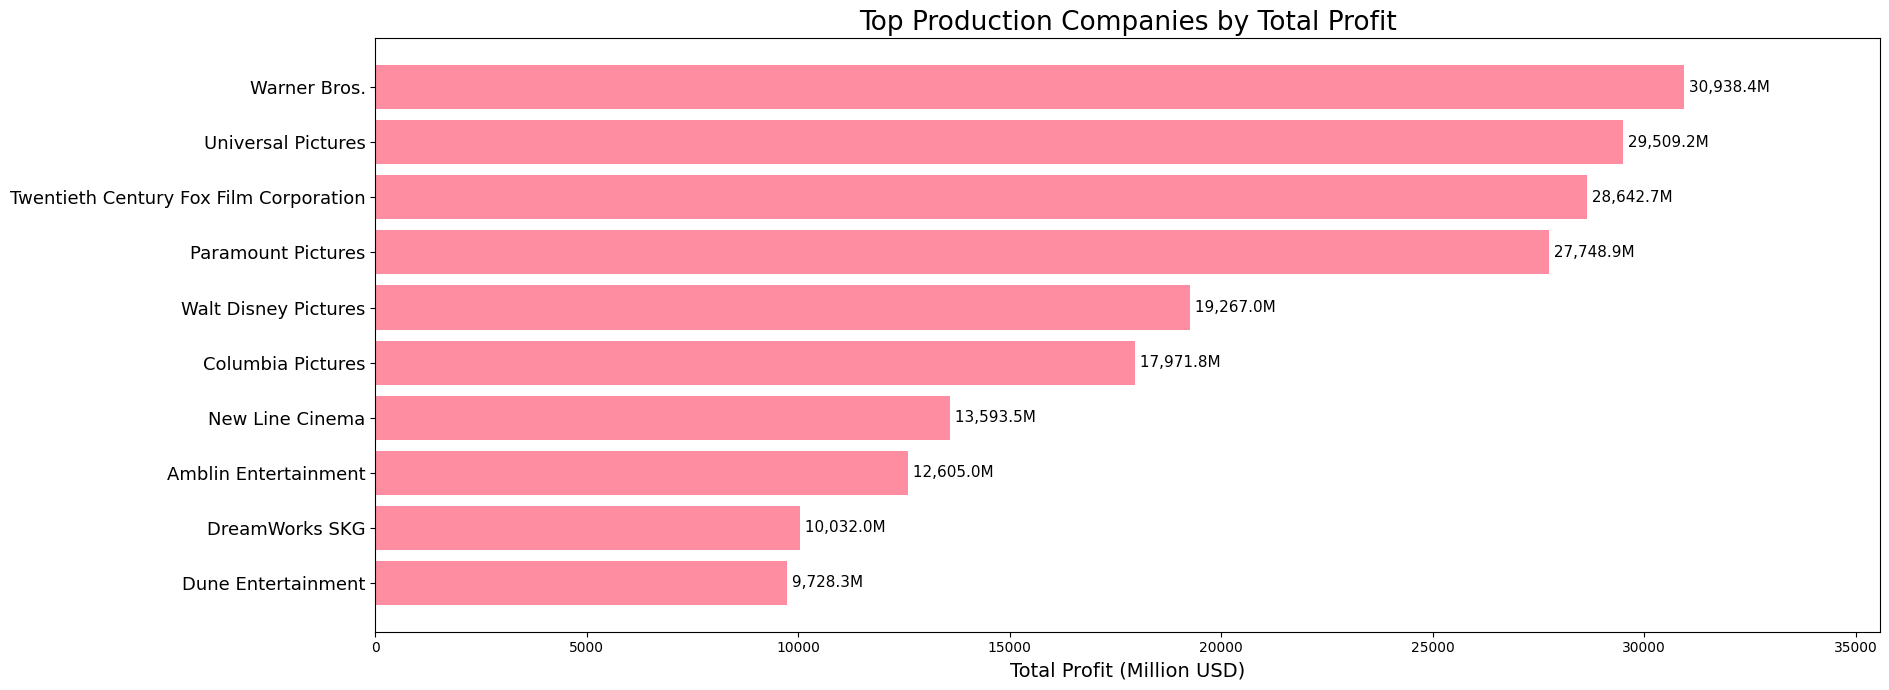

In [22]:
df_q1 = pd.read_sql_query(query_1, conn)


df_q1['total_profit_millions'] = df_q1['total_profit'] / 1_000_000
df_q1 = df_q1.sort_values('total_profit_millions', ascending=True)

plt.figure(figsize=(19, 7))
plt.barh(df_q1['company_name'], df_q1['total_profit_millions'], color = '#FF8DA1')

plt.xlabel('Total Profit (Million USD)', fontsize = 14)
plt.title('Top Production Companies by Total Profit', fontsize = 19)
plt.yticks(fontsize=13)
for i, value in enumerate(df_q1['total_profit_millions']):
    plt.text(value, i, f' {value:,.1f}M', va='center', fontsize=11)

plt.xlim(0, df_q1['total_profit_millions'].max() * 1.15)

plt.tight_layout()
plt.show()

#### **Key Findings**

The data reveals a significant concentration of wealth among a few major studios, led by **Warner Bros.** and **Universal Pictures**.

- **Market Dominance**: The top players show a **massive gap** in total profit compared to smaller competitors, highlighting the "blockbuster" business model where high-volume production leads to billions in cumulative profit.

- **Profit vs. Efficiency**: Interestingly, while Warner Bros. leads in total profit, companies like Paramount often show a higher Average ROI, suggesting that **total wealth doesn't always correlate with individual project efficiency**.

### **2. ROI by Movie Budget Level**

This query separates the movies into **four distinct categories** based on their **production budget**. By calculating the Average ROI for each "level", we can evaluate which investment strategy is most efficient from a financial standpoint. This helps determine if spending more money on a movie actually results in a better proportional return compared to smaller, lower-budget productions.

In [23]:
#ROI by Budget Level
query_2 = '''
SELECT 
    CASE 
        WHEN budget >= 100000000 THEN '$100M+'
        WHEN budget BETWEEN 50000000 AND 99999999 THEN '$50M-$99M'
        WHEN budget BETWEEN 10000000 AND 49999999 THEN '$10M-$49M'
        ELSE '< $10M'
    END AS budget_level,
    COUNT(movie_id) AS total_movies,
    ROUND(AVG(profit), 2) AS avg_profit,
    ROUND(AVG(ROI), 2) AS avg_roi
FROM fact_table
WHERE budget > 0 AND profit IS NOT NULL AND ROI IS NOT NULL
GROUP BY budget_level
ORDER BY budget_level;
'''
display(pd.read_sql_query(query_2, conn))

,budget_level,total_movies,avg_profit,avg_roi
0,$100M+,318,305568971.28,1.99
1,$10M-$49M,1541,51920882.30,2.35
2,$50M-$99M,638,102205300.32,1.49
3,< $10M,732,24361082.97,13022.80


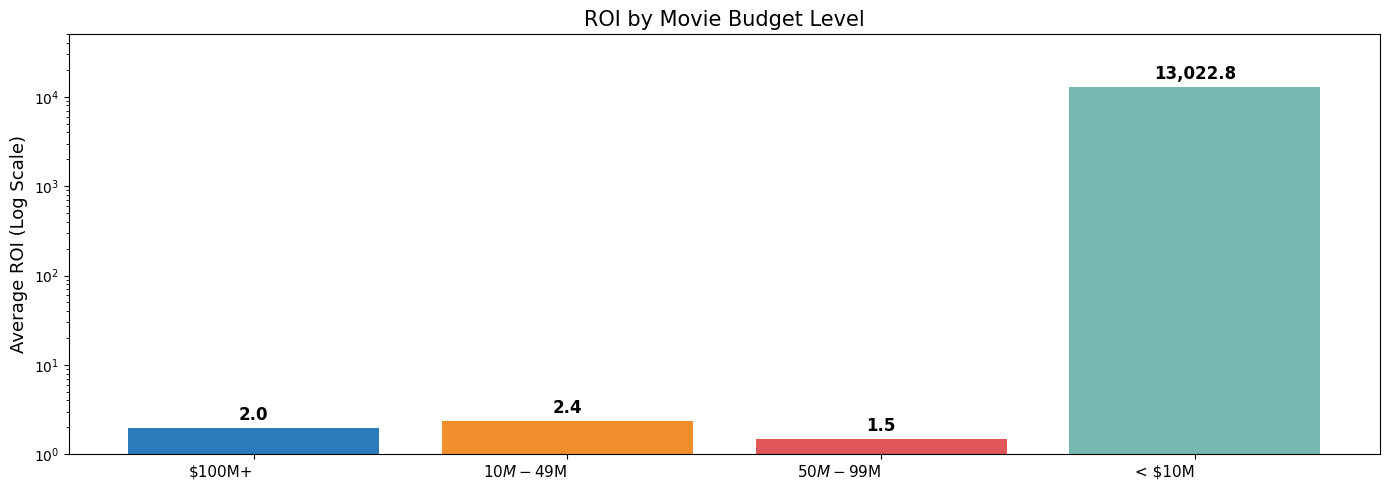

In [24]:
df_q2 = pd.read_sql_query(query_2, conn)
labels = df_q2['budget_level']
values = df_q2['avg_roi']
colors = ['#2b7bba', '#f28e2b', '#e15759', '#76b7b2']

plt.figure(figsize=(14, 5))


bars = plt.bar(labels, values, color=colors)
plt.yscale('log')


    
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height * 1.1,
             f'{height:,.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel('Average ROI (Log Scale)', fontsize=13)
plt.title('ROI by Movie Budget Level', fontsize=15)
plt.xticks(ha='right', fontsize=11)

# Ajustar limites para o texto não sair do quadrado
plt.ylim(1, 50000)

plt.tight_layout()
plt.show()

#### **Key Findings and Conclusion**

The results present a **striking contrast** between commercial profit and investment efficiency, visualized through a **logarithmic** perspective to handle significant data variance:

- **The Low-Budget Paradox:** The "Low Budget" category shows an astronomical Average ROI of **13,022.80**. This is driven by "outlier" films that **cost very little but earn millions**. Using a logarithmic scale is essential here to capture this massive peak without losing the detail of the other categories.

- **Stability in the Middle:** The Mid Budget ($10M-$49M) level shows a healthy and more realistic ROI of **2.35**, outperforming the higher-budget segments. This suggests that mid-sized productions often find the **"sweet spot" between production value and profitability**.

- **Diminishing Returns:** High Budget films, despite making the **most total profit, have the lowest proportional returns (1.99 and 1.49 respectively)**. This confirms that as budgets grow, the **financial risk increases** while the relative efficiency of each dollar invested tends to decrease.

### **3. Average Profit by Genre**

This analysis explores the **financial viability of different movie genres** by calculating their **Average Profit**.
By joining the fact table with the genres dimension, we can identify which types of stories are currently the **most lucrative** for studios.

In [25]:
query_3 = '''
-- Query 3: Genre Profitability & Efficiency
SELECT 
    g.genre_name, 
    COUNT(f.movie_id) AS film_count,
    ROUND(AVG(f.profit), 2) AS avg_profit,
    ROUND(AVG(f.ROI), 2) AS avg_roi
FROM fact_table f
JOIN dim_genres g ON f.movie_id = g.movie_id
WHERE f.profit IS NOT NULL AND f.ROI IS NOT NULL
GROUP BY g.genre_name
ORDER BY avg_profit DESC;
'''

display(pd.read_sql_query(query_3, conn))

,genre_name,film_count,avg_profit,avg_roi
0,Animation,188,198090651.16,5.09
1,Adventure,661,170714153.23,3.46
2,Fantasy,342,162675510.32,4.82
3,Family,365,157588117.39,4.16
4,Science Fiction,431,125956782.61,4.93
5,Action,918,114424359.21,2.58
6,Comedy,1110,72323909.89,7662.07
7,Thriller,935,69233752.75,1073.90
8,Romance,574,64263807.27,4.09
9,Mystery,265,63308118.43,66.76


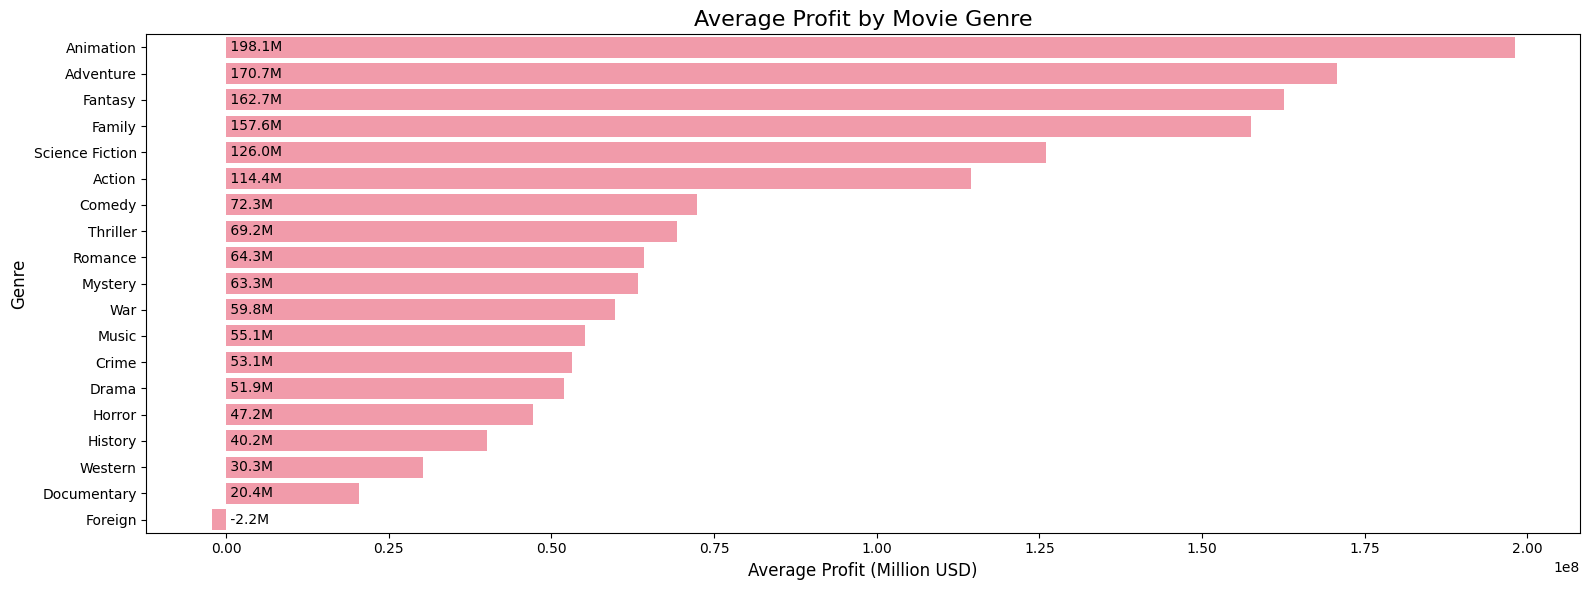

In [26]:
df_genres = pd.read_sql_query(query_3, conn)
df_genres['avg_profit_millions'] = df_genres['avg_profit'] / 1_000_000

plt.figure(figsize=(16, 6))
ax = sns.barplot(data=df_genres, x='avg_profit', y='genre_name', color = '#FF8DA1' )

plt.title('Average Profit by Movie Genre', fontsize=16)
plt.xlabel('Average Profit (Million USD)', fontsize=12)
plt.ylabel('Genre', fontsize=12)

for i, value in enumerate(df_genres['avg_profit_millions']):
    ax.text(value, i, f' {value:,.1f}M', va='center')

plt.tight_layout()
plt.show()

#### **Key Findings and Conclusion**

The visualization highlights a **clear hierarchy in genre profitability**:

- **The Dominance of Animation & Adventure**: Animation leads the market with an average profit of 198.1M, followed closely by Adventure (170.7M) and Fantasy (162.7M). This suggests that family-oriented content **consistently achieves the highest global box office returns**.

- **The Middle Ground:** Commercial genres like Comedy (72.3M) and Thriller (69.2M) show solid performance but sit significantly below the big-budget spectacle genres.

- **Less Audience**: Documentaries (20.4M) and Westerns (30.3M) appear at the bottom of the list. While they can be profitable, their lower average profit indicates a **more limited audience** reach compared to major studio genres.

- **The "Foreign" Market**: A critical insight from this data is the **negative average profit** for the Foreign category (-2.2M). This suggests that movies labeled primarily as foreign in this dataset **struggle to recoup their costs, likely due to limited international distribution or lower marketing budgets** compared to Hollywood mainstream genres.

### **4. Top 10 Actors by Average Audience Score**

This query evaluates the **"Star Power"**  of the cast from a **qualitative perspective**. 
Instead of looking at box office numbers, we measure the **Average Audience Score** to identify actors who consistently participate in high-quality projects. By filtering for actors with **at least 5 films**, we ensure that the results reflect career consistency rather than one-off successes.

In [27]:
#Top 10 Actors by Average Audience Score
query_4 = '''
SELECT 
    c.actor_name, 
    COUNT(f.movie_id) AS film_count,
    ROUND(AVG(f.vote_average), 2) AS avg_audience_score,
    SUM(f.vote_count) AS total_votes_received
FROM fact_table f
JOIN dim_cast c ON f.movie_id = c.movie_id
GROUP BY c.actor_name
HAVING film_count >= 5
ORDER BY avg_audience_score DESC
LIMIT 10;'''

display(pd.read_sql_query(query_4, conn))

,actor_name,film_count,avg_audience_score,total_votes_received
0,Russ Fega,5,7.98,42144
1,Richard Bright,5,7.84,11911
2,Burnell Tucker,6,7.72,18441
3,Pete Docter,5,7.68,30874
4,Chuck Hamilton,5,7.68,2827
5,Gino Corrado,6,7.67,3088
6,Jack Purvis,5,7.66,18278
7,Joseph Oliveira,10,7.63,50902
8,Clem Caserta,5,7.60,7131
9,Harry Northup,5,7.54,8339


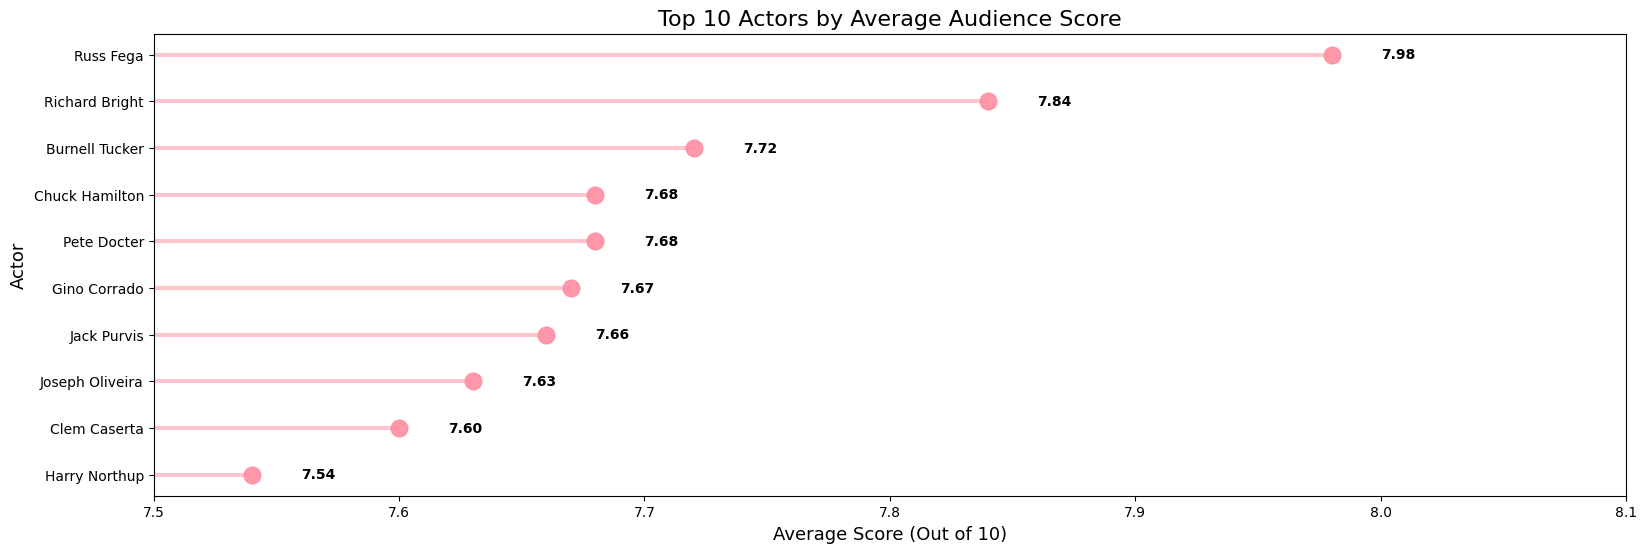

In [28]:

df_cast = pd.read_sql_query(query_4, conn)

df_cast = df_cast.sort_values('avg_audience_score', ascending=True)

plt.figure(figsize=(19, 6))

plt.hlines(y=df_cast['actor_name'], xmin=7.5, xmax=df_cast['avg_audience_score'], 
           color='#FF8DA1', alpha=0.5, linewidth=3)
plt.plot(df_cast['avg_audience_score'], df_cast['actor_name'], "o", 
         markersize=12, color='#FF8DA1', alpha=0.9)


for i, value in enumerate(df_cast['avg_audience_score']):
    plt.text(value + 0.02, i, f'{value:.2f}', va='center', fontweight='bold')

plt.title('Top 10 Actors by Average Audience Score', fontsize=16)
plt.xlabel('Average Score (Out of 10)', fontsize=13)
plt.ylabel('Actor', fontsize=13)
plt.xlim(7.5, 8.1)

plt.tight_layout
plt.show()

#### **Key Findings and Conclusion**

The audience score analysis reveals an **interesting pattern of prestige actors**:

- **Quality Consistency**: Russ Fega leads the ranking with an impressive **7.98** average score. This indicates that these actors, while perhaps not always the lead stars in blockbusters, are associated with critically acclaimed or highly-rated films.

- **High Engagement**: Most of these actors have a significant number of total votes received (e.g., Russ Fega with over 42,000 votes), which confirms that these high scores are **statistically solid** and not just based on a handful of fans.

### **5. Average Popularity by Release Day**

This analysis examines the **impact of release timing on a movie's success**. By grouping the data by the day of the week, we can **identify patterns** in industry behavior (when studios choose to release films) versus audience engagement (when films actually gain more popularity). This strategic insight is crucial for optimizing marketing campaigns and selecting the ideal release window.

In [29]:
query_5 = '''SELECT 
    d.day_of_week, 
    COUNT(f.movie_id) AS release_count,
    ROUND(AVG(f.popularity), 2) AS avg_popularity
FROM fact_table f
JOIN dim_date d ON f.movie_id = d.movie_id
GROUP BY d.day_of_week
ORDER BY avg_popularity DESC;
'''

display(pd.read_sql_query(query_5, conn))

,day_of_week,release_count,avg_popularity
0,Wednesday,795,32.69
1,Tuesday,351,26.42
2,Thursday,915,24.70
3,Monday,233,20.99
4,Saturday,236,16.77
5,Friday,2053,16.27
6,Sunday,217,14.29


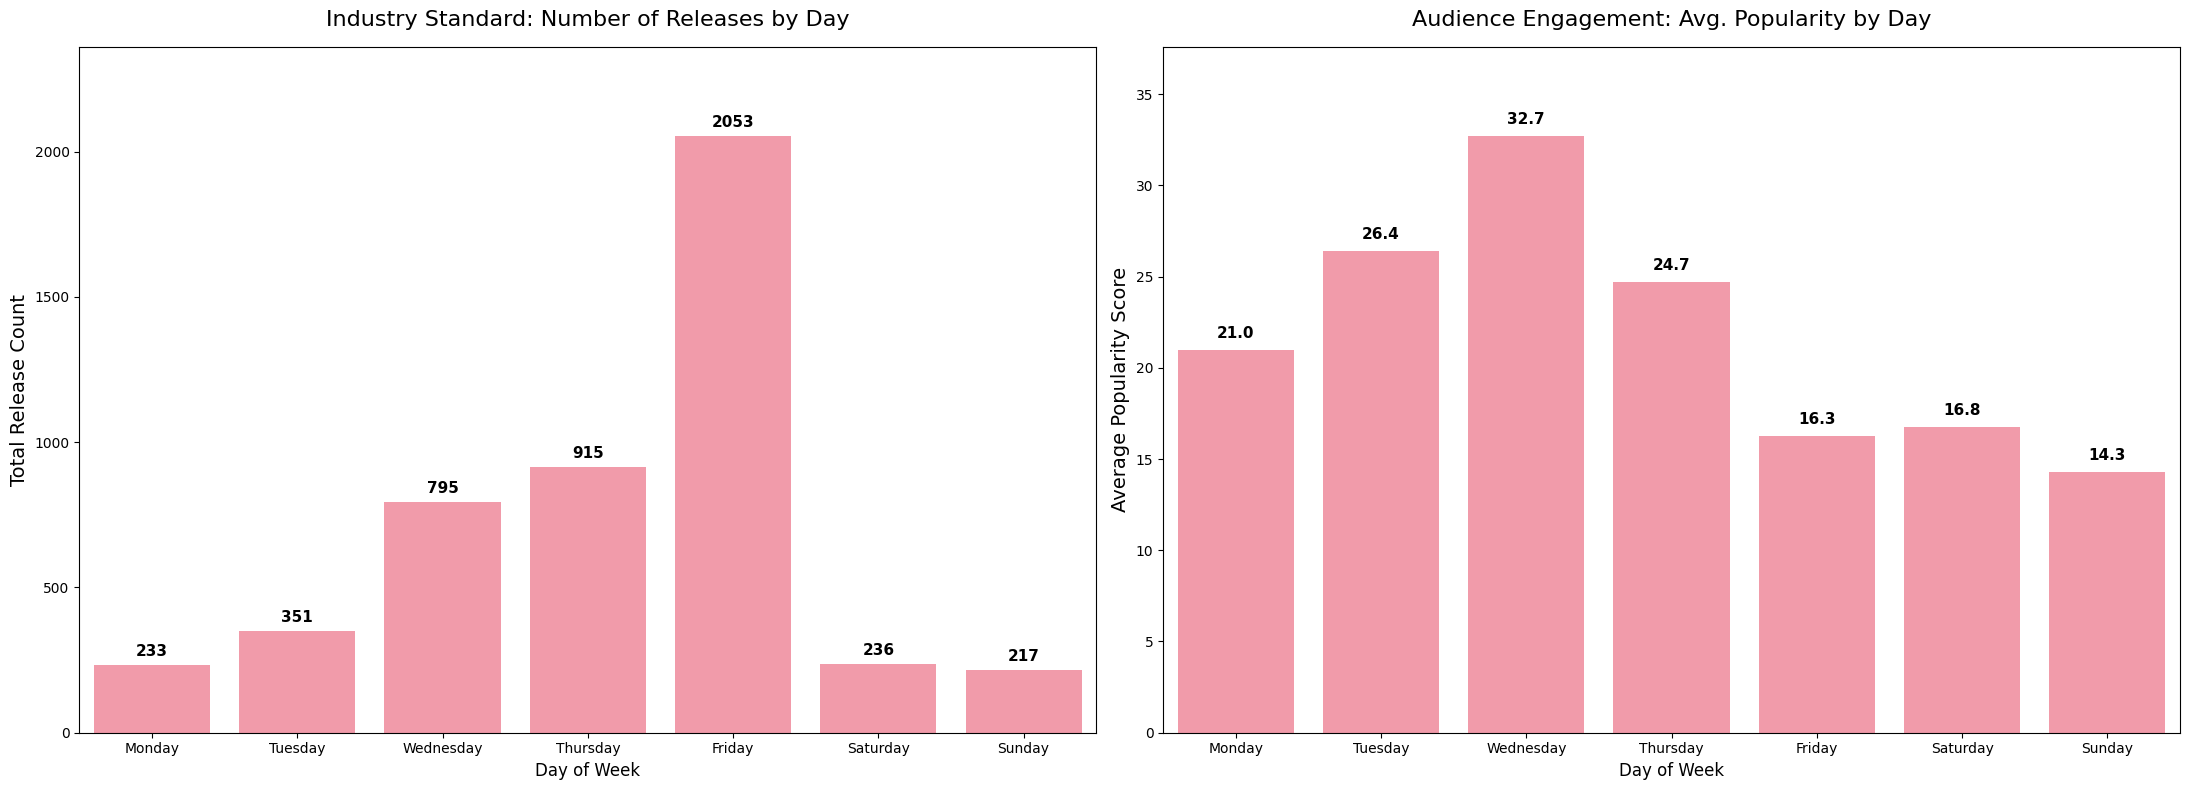

In [30]:

df_days = pd.read_sql_query(query_5, conn)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_days['day_of_week'] = pd.Categorical(df_days['day_of_week'], categories=day_order, ordered=True)
df_days = df_days.sort_values('day_of_week')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# Number of Movie Releases 
sns.barplot(data=df_days, x='day_of_week', y='release_count', color='#FF8DA1', ax=ax1)
ax1.set_title('Industry Standard: Number of Releases by Day', fontsize=16, pad=15)
ax1.set_xlabel('Day of Week', fontsize=12)
ax1.set_ylabel('Total Release Count', fontsize=14)
ax1.set_ylim(0, df_days['release_count'].max() * 1.15)

for i, value in enumerate(df_days['release_count']):
    ax1.text(i, value + 20, f'{int(value)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

#Average Popularity (Performance)
sns.barplot(data=df_days, x='day_of_week', y='avg_popularity', color='#FF8DA1', ax=ax2)
ax2.set_title('Audience Engagement: Avg. Popularity by Day', fontsize=16, pad=15)
ax2.set_xlabel('Day of Week', fontsize=12)
ax2.set_ylabel('Average Popularity Score', fontsize=14)
ax2.set_ylim(0, df_days['avg_popularity'].max() * 1.15)

for i, value in enumerate(df_days['avg_popularity']):
    ax2.text(i, value + 0.5, f'{value:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

#### **Key Findings and Conclusion**

The side-by-side comparison reveals a clear strategic gap in film distribution:

- **The Friday Dominance:** The first chart shows that **Friday is the industry's default choice**, with over 2,000 releases, overcoming all other days.

- **The Wednesday Opportunity**: However, the second chart proves that Wednesday releases actually drive the highest audience engagement (**32.7 popularity**), which is double the popularity of Friday releases (16.3).

- **Strategic Insight**: This suggests that mid-week releases, often reserved for "event" movies or major franchise launches, are significantly **more effective at capturing audience attention than the crowded Friday window**.



<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a ></a>Exports</b></h3>

In [31]:
tables = pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name;
""", conn)

display(tables)


,name
0,dim_cast
1,dim_date
2,dim_genres
3,dim_production
4,fact_table


In [32]:
tables_to_export = [
    "fact_table",
    "dim_date",
    "dim_genres",
    "dim_cast",
    "dim_production"
]

for table_name in tables_to_export:
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    df.to_csv(f"{table_name}.csv", index=False, encoding="utf-8-sig")

conn.close()

<div style="background-color:#FDD5DF; padding:10px; border-radius:14px; border-left:10px solid #FF8DA1;">
<h3><b> <a id="conclusion" ></a>Conclusion </b></h3>

### **Project Conclusion & Executive Summary**

**Technical Achievement**

Through this project, we successfully designed and implemented a fully functional **Data Warehouse** utilizing a **Star Schema** architecture. By transforming a raw, complex movie dataset (TMDB 5000) into a structured environment with a central Fact Table and specialized Dimension Tables (Date, Genres, Production, and Cast), we achieved a system that optimizes query performance, cleans nested JSON data, and ensures data integrity.

**Business Intelligence Insights**

The analytical phase proved that this Data Warehouse is a powerful engine for strategic decision-making in the film industry, moving beyond simple revenue tracking to uncover real market behavior:

* **Financial Powerhouses:** We identified the dominant market players, revealing a massive concentration of wealth among a few major studios like Warner Bros. and Universal Pictures.
* **The Budget Paradox:** Our ROI analysis proved that while Mega Blockbusters generate the highest absolute profit, **Low and Mid-budget films** offer significantly higher investment efficiency, challenging the idea that "bigger is always better."
* **Content Strategy:** By analyzing genres, we discovered that **Animation and Adventure** consistently achieve the highest global returns, whereas niche categories like "Foreign" films struggle to break even in this market.
* **Talent & Prestige:** The cast analysis allowed us to measure "Star Power" through audience satisfaction, identifying actors who consistently bring a seal of quality and trust to their projects.
* **Distribution Optimization:** Our temporal analysis revealed a critical strategic gap: while the industry defaults to **Friday** for the vast majority of releases, it is actually **Wednesday** that drives the highest average audience engagement and popularity.

**Final Considerations**
In conclusion, this project demonstrates the end-to-end journey of data: from raw, messy CSV files to **actionable business intelligence**. The insights derived here provide a data-driven roadmap for production, casting, and distribution, proving that a well-structured Data Warehouse is an essential tool for any modern studio aiming to mitigate risk and maximize global impact.